In [90]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import LeaveOneGroupOut,TimeSeriesSplit
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder,FunctionTransformer,PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
      f1_score,fbeta_score, recall_score, precision_score,
      roc_auc_score, average_precision_score,roc_curve, auc,precision_recall_curve,
      brier_score_loss, confusion_matrix, ConfusionMatrixDisplay
  )
#from sklearn.metrics import fbeta_score
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.base import BaseEstimator, TransformerMixin
from interpret.glassbox import ExplainableBoostingClassifier
from interpret import show, set_visualize_provider
from interpret.provider import InlineProvider
from interpret import show



# Data file imported

In [91]:
data=pd.read_csv("aurora_dataset_clean.csv")

Target: `see_aurora` , features: `featureslow`, we would like to exclude some impossible events which are marked as positive aurora sighting, i.e. during sun way up above the horizon. We dont want to be too resticitve given in polar regions the (sun elevation angle) `sun_elevation_UTC` may not reach $6^{\degree}$ during certain seasons. Also we are mindful of observers reporting wrong time (i.e. not UTC time but their localtime) and therefore also calculate if sun elevation angle `sun_elevation_localtime` exceeds $6^{\degree}$. If both are yes the sighting was most likely suprious due to light pollution and we turn the `see_aurora` variable False for that observation.

In [92]:
day_of_year = pd.to_datetime(data["date"]).dt.dayofyear
declination = np.radians(23.45 * np.sin(np.radians(360/365 * (day_of_year - 81))))
lat_rad = np.radians(data['latitude'])

  # Max elevation = solar noon elevation
data['solar_noon_elev_max'] = np.degrees(
    np.arcsin(
        np.sin(lat_rad) * np.sin(declination) +
        np.cos(lat_rad) * np.cos(declination)
    )
)
polar_winter = data["solar_noon_elev_max"] <= 6
dark_enough = ((data["sun_elevation_localtime"] <= 6) | (data["sun_elevation_utc"] <= 6))

In [93]:
features0 = ["mlat","mlon","kp","bz_gsm","solar_wind_speed","oval_dist","Ap"]
features1 = ["mlat","mlon","mlt","kp","bz_gsm","sigma_bz_gsm","solar_wind_speed","ap","Ap"]
features2 = ["cloud_cover","visibility","moon_phase","moon_darkness","sun_elevation_utc","sun_elevation_localtime"]
featureslow = ["mlat","mlon","kp","bz_gsm","solar_wind_speed","oval_dist","Ap","cloud_cover","moon_darkness","sun_elevation_utc"]
features1primary0 = ["mlat","mlon","kp","bz_gsm","solar_wind_speed"]
features2primary = ["cloud_cover","moon_darkness","sun_elevation_utc"]
target = "see_aurora"



In [94]:
clean_columns=data.columns[~data.isna().any()].tolist()

In [95]:
dataclean=data.dropna(subset=features1primary0,how='any',inplace=False)

In [96]:
mymodifiedsighting1 = dataclean[['sun_elevation_utc','sun_elevation_localtime','solar_noon_elev_max',"see_aurora"]]
mymodifiedsighting1["see_aurora"] = ((mymodifiedsighting1["see_aurora"] == True) & (polar_winter | dark_enough))
dataclean["see_aurora"]=mymodifiedsighting1["see_aurora"]

In [97]:
removed_mask = ~(polar_winter | dark_enough)

print(f'Removed positives: {removed_mask.sum()}')
print()
print(pd.cut(
      dataclean.loc[removed_mask, 'mlat'].abs(),
      bins=[0, 45, 55, 62, 75, 90],
      labels=['0-45','45-55','55-62','62-75','75-90']).value_counts().sort_index())

Removed positives: 3110

mlat
0-45      551
45-55    1917
55-62     481
62-75     121
75-90       1
Name: count, dtype: int64


In [98]:
fill_values = {
      'solar_wind_speed': 9999.9,
      'bz_gsm':          999.9,
      'sigma_bz_gsm':    999.9,
      'kp':              99,
      'ap':              999,
      'Ap':              999,
  }

for col, fill in fill_values.items():
      if col in dataclean.columns:
          n = (dataclean[col] >= fill * 0.9).sum()  # 90% of fill to catch rounding
          print(f'{col:20s}: {n:>6,} rows with fill value')

mask_valid = (
      (dataclean['solar_wind_speed'] < 9000) &
      (dataclean['bz_gsm'].abs()     < 900)  &
      (dataclean['sigma_bz_gsm']     < 900)  &
      (dataclean['kp']               < 90)   &
      (dataclean['ap']               < 900)  &
      (dataclean['Ap']               < 900)  )

print(f'Rows before: {len(dataclean):,}')
dataclean = dataclean[mask_valid].copy()
print(f'Rows after:  {len(dataclean):,}')
print(f'Dropped:     {(~mask_valid).sum():,}')

solar_wind_speed    :     55 rows with fill value
bz_gsm              :      0 rows with fill value
sigma_bz_gsm        :      0 rows with fill value
kp                  :      0 rows with fill value
ap                  :      0 rows with fill value
Ap                  :      0 rows with fill value
Rows before: 22,186
Rows after:  22,131
Dropped:     55


 Make use of the approximate equatorward auroral oval boundary (Feldstein & Starkov 1967) relation, Positive = observer inside/above oval, negative = outside (aurora unlikely), Here we are using Zhang & Paxton (2008) formula

In [99]:
# (Feldstein & Starkov 1967) # Positive = observer inside/above oval, negative = outside (aurora unlikely)
#dataclean["oval_dist"] = dataclean["mlat"].abs()-(67.5-2.5*dataclean["kp"]) 
mlt_angle = np.pi * (dataclean['mlt'] - 0) / 12
dataclean['oval_dist'] = (
      dataclean['mlat'].abs()
      - (65.2 - 2.4 * dataclean['kp'] + 3.0 * np.cos(mlt_angle)))

In [100]:
dataclean['utc_dt'] = pd.to_datetime(dataclean['utc_dt'],format='ISO8601', utc=True) 
dataclean_timesorted = dataclean.sort_values('utc_dt').reset_index(drop=True)
dataclean_timesorted['mlat_band']= pd.cut(dataclean_timesorted["mlat"].abs(),bins=[0,48,63,90],labels=["00-48","48-63","63-90"])

In [122]:
print(dataclean_timesorted[features1].corr())

                      mlat      mlon       mlt        kp    bz_gsm  \
mlat              1.000000  0.186548  0.035885 -0.072653  0.037273   
mlon              0.186548  1.000000  0.000556  0.100959 -0.094718   
mlt               0.035885  0.000556  1.000000  0.125980 -0.075966   
kp               -0.072653  0.100959  0.125980  1.000000 -0.696567   
bz_gsm            0.037273 -0.094718 -0.075966 -0.696567  1.000000   
sigma_bz_gsm     -0.054728  0.103847  0.102558  0.702101 -0.622455   
solar_wind_speed -0.052541  0.009483  0.033714  0.229740 -0.075948   
ap               -0.099175  0.125556  0.115871  0.887371 -0.788169   
Ap               -0.103652  0.002878  0.096654  0.773415 -0.510055   

                  sigma_bz_gsm  solar_wind_speed        ap        Ap  
mlat                 -0.054728         -0.052541 -0.099175 -0.103652  
mlon                  0.103847          0.009483  0.125556  0.002878  
mlt                   0.102558          0.033714  0.115871  0.096654  
kp             

Break the available data for train and test set keeping the time order. Within the train set split the training data using timeseriessplit for crossvalidation over three `mlat` bands

In [101]:
dataclean_timesorted_alt_train =  dataclean_timesorted[dataclean_timesorted['utc_dt'] <= "2024-07-01"] 
dataclean_timesorted_alt_test =  dataclean_timesorted[dataclean_timesorted['utc_dt'] > "2024-07-01"]

gap = 2 chosen such that same aurora event reported in two consecutive measurements do not spill over folds, maybe not important

In [102]:
tscvtrain=TimeSeriesSplit(n_splits=3, gap=2 )
leavego=LeaveOneGroupOut()

In [103]:
preprocess = ColumnTransformer(transformers=[("sine_mlon",FunctionTransformer(lambda x: np.sin(x)),["mlon"]),
                                                     ("cosine_mlon",FunctionTransformer(lambda x: np.cos(x)),["mlon"])],remainder='passthrough')

In [104]:
feat_names2 = ['sin_mlon', 'cos_mlon'] + [f for f in features0 if f !='mlon'] + [g for g in features2primary]
interactions = [(3,4),(3,5),(4,5)] #[(2,3),(2,4),(3,4)] #(2,3)(3, 4),(3, 5),, 
print("Feature names:", feat_names2)
print("Interactions: ", [(feat_names2[i], feat_names2[j]) for i, j in interactions])

Feature names: ['sin_mlon', 'cos_mlon', 'mlat', 'kp', 'bz_gsm', 'solar_wind_speed', 'oval_dist', 'Ap', 'cloud_cover', 'moon_darkness', 'sun_elevation_utc']
Interactions:  [('kp', 'bz_gsm'), ('kp', 'solar_wind_speed'), ('bz_gsm', 'solar_wind_speed')]


In [105]:
pipeebm2=Pipeline(steps=[('prepro',preprocess),
                        ("EBM",ExplainableBoostingClassifier(feature_names=feat_names2,interactions=interactions,max_bins=128,max_rounds=1000,min_samples_leaf=5,random_state=42))])

In [106]:
def per_band_weights(y, bands):
      y     = np.array(y)
      bands = np.array(bands)
      weights = np.ones(len(y), dtype=float)
      for band in np.unique(bands[~pd.isnull(bands)]):
          mask  = bands == band
          y_b   = y[mask]
          n_neg = (y_b == False).sum()
          n_pos = (y_b == True).sum()
          n_tot = len(y_b)
          if n_neg > 0:
              weights[mask & (y == False)] = n_tot / (2 * n_neg)
          if n_pos > 0:
              weights[mask & (y == True)]  = n_tot / (2 * n_pos)
      return weights

In [107]:
fit_results2=[]
for t_fold, (t_train,t_val) in enumerate(tscvtrain.split(dataclean_timesorted_alt_train)):
    tsdata_train= dataclean_timesorted_alt_train.iloc[t_train]
    tsdata_val=dataclean_timesorted_alt_train.iloc[t_val]
    mlat_regions = tsdata_val["mlat_band"].dropna().unique()
    for regions in mlat_regions:
        train_mask = tsdata_train["mlat_band"] != regions
        val_mask = tsdata_val["mlat_band"] == regions
        X_train = tsdata_train.loc[train_mask,featureslow]
        mlat_band_train = tsdata_train.loc[train_mask, 'mlat_band']
        X_val = tsdata_val.loc[val_mask,featureslow]
        y_train = tsdata_train.loc[train_mask,target].astype(int)
        y_val = tsdata_val.loc[val_mask,target].astype(int)



# maybe lower threshold 
      #  threshold = 0.3
        sw = per_band_weights(y_train, mlat_band_train)
        pipeebm2.fit(X_train,y_train,EBM__sample_weight=sw)
        print("Band counts in this training fold:")
        print(tsdata_train.loc[train_mask, 'mlat_band'].value_counts())
        print()   
        print("Weight stats per band:")
        bands_arr = np.array(tsdata_train.loc[train_mask, 'mlat_band'])
        y_arr     = np.array(y_train)
        for band in np.unique(bands_arr[~pd.isnull(bands_arr)]):
            mask = bands_arr == band
            print(f"  {band}: neg_w={sw[mask & (y_arr==0)][0]:.4f}  pos_w={sw[mask & (y_arr==1)][0]:.4f}  n={mask.sum()}")
      

        
        y_predict_train_prob = pipeebm2.predict_proba(X_train)[:,1]
        y_predict_train= (y_predict_train_prob >= 0.5).astype(int) 
        y_predict_val_prob= pipeebm2.predict_proba(X_val)[:,-1]
        y_predict_val= (y_predict_val_prob >= 0.5).astype(int) 

        train_scores = {
      'f1'        : f1_score(y_train, y_predict_train),
      'recall'    : recall_score(y_train, y_predict_train),
      'precision' : precision_score(y_train, y_predict_train),
      'roc_auc'   : roc_auc_score(y_train, y_predict_train_prob),
      'pr_auc'    : average_precision_score(y_train, y_predict_train_prob),  
      'brier'     : brier_score_loss(y_train, y_predict_train)}

        val_scores = {
      'f1'        : f1_score(y_val, y_predict_val,zero_division=0),
      'recall'    : recall_score(y_val, y_predict_val,zero_division=0),
      'precision' : precision_score(y_val, y_predict_val,zero_division=0),
      'roc_auc'   : roc_auc_score(y_val, y_predict_val_prob),
      'pr_auc'    : average_precision_score(y_val, y_predict_val_prob),  
      'brier'     : brier_score_loss(y_val, y_predict_val_prob)}
    #    fit_results.append({'t_fold': t_fold, 'mlat_band': str(regions),**{f'train_{k}':v for k, v in train_scores.items()},**{f'val_{k}':v for k, v in val_scores.items()}})
        fit_results2.append({
      't_fold':    t_fold,
      'mlat_band': str(regions),          
      'y_val':     list(y_val),      
      'y_pred':    list(y_predict_val),  
      'y_prob':    list(y_predict_val_prob),
      **{f'train_{k}': v for k, v in train_scores.items()},
      **{f'val_{k}':   v for k, v in val_scores.items()},}) 
        fit_results2_df = pd.DataFrame(fit_results2)
        bands = fit_results2_df['mlat_band'].unique()
        print(f'fold={t_fold} band={regions} train={len(X_train)} val={len(X_val)}')

Band counts in this training fold:
mlat_band
63-90    646
00-48    188
48-63      0
Name: count, dtype: int64

Weight stats per band:
  00-48: neg_w=0.6763  pos_w=1.9184  n=188
  63-90: neg_w=3.8000  pos_w=0.5758  n=646
fold=0 band=48-63 train=834 val=2630
Band counts in this training fold:
mlat_band
48-63    2624
00-48     188
63-90       0
Name: count, dtype: int64

Weight stats per band:
  00-48: neg_w=0.6763  pos_w=1.9184  n=188
  48-63: neg_w=1.6545  pos_w=0.7165  n=2624
fold=0 band=63-90 train=2812 val=535
Band counts in this training fold:
mlat_band
48-63    2624
63-90     646
00-48       0
Name: count, dtype: int64

Weight stats per band:
  48-63: neg_w=1.6545  pos_w=0.7165  n=2624
  63-90: neg_w=3.8000  pos_w=0.5758  n=646
fold=0 band=00-48 train=3270 val=292
Band counts in this training fold:
mlat_band
63-90    1183
00-48     480
48-63       0
Name: count, dtype: int64

Weight stats per band:
  00-48: neg_w=0.6667  pos_w=2.0000  n=480
  63-90: neg_w=3.3418  pos_w=0.5880  n=11

In [108]:
ebm_global2 = pipeebm2.named_steps['EBM'].explain_global()
show(ebm_global2)

<!-- http://127.0.0.1:7381/140106480351376/ -->

In [109]:
print(fit_results2_df[['t_fold', 'mlat_band', 'val_f1', 'val_recall','val_precision', 'val_roc_auc']].to_string())

   t_fold mlat_band    val_f1  val_recall  val_precision  val_roc_auc
0       0     48-63  0.699770    0.629213       0.788148     0.714853
1       0     63-90  0.903366    0.939052       0.870293     0.720998
2       0     00-48  0.173913    0.112676       0.380952     0.721943
3       1     48-63  0.814013    0.840588       0.789067     0.708911
4       1     63-90  0.822134    1.000000       0.697987     0.670569
5       1     00-48  0.830315    0.964174       0.729093     0.813456
6       2     48-63  0.354839    0.290429       0.455959     0.451863
7       2     00-48  0.276488    0.275100       0.277890     0.474409
8       2     63-90  0.500000    1.000000       0.333333     0.777778


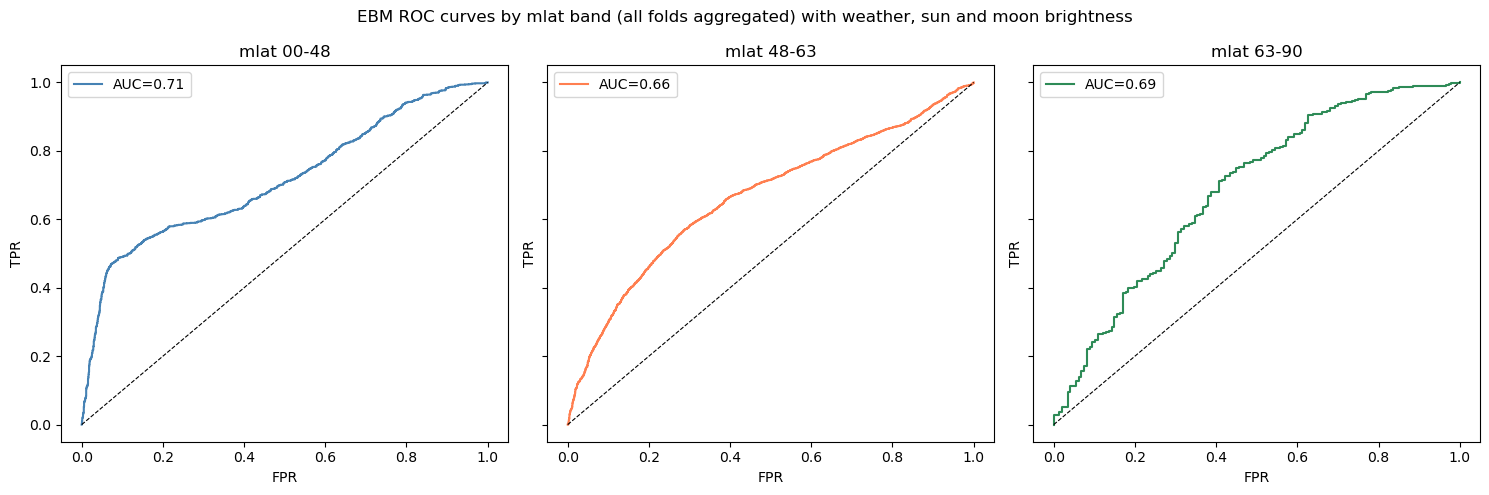

In [110]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
bands = sorted(fit_results2_df['mlat_band'].unique())
colors = ['steelblue', 'coral', 'seagreen']

for ax, band, color in zip(axes, bands, colors):
      grp = fit_results2_df[fit_results2_df['mlat_band'] == band]
      y_true_all = sum(grp['y_val'].tolist(), [])
      y_prob_all = sum(grp['y_prob'].tolist(), [])

      fpr, tpr, _ = roc_curve(y_true_all, y_prob_all)
      roc_auc = auc(fpr, tpr)
      ax.plot(fpr, tpr, color=color, label=f'AUC={roc_auc:.2f}')
      ax.plot([0,1],[0,1],'k--', linewidth=0.8)
      ax.set(title=f'mlat {band}', xlabel='FPR', ylabel='TPR')
      ax.legend()

plt.suptitle('EBM ROC curves by mlat band (all folds aggregated) with weather, sun and moon brightness')
plt.tight_layout()
plt.show()

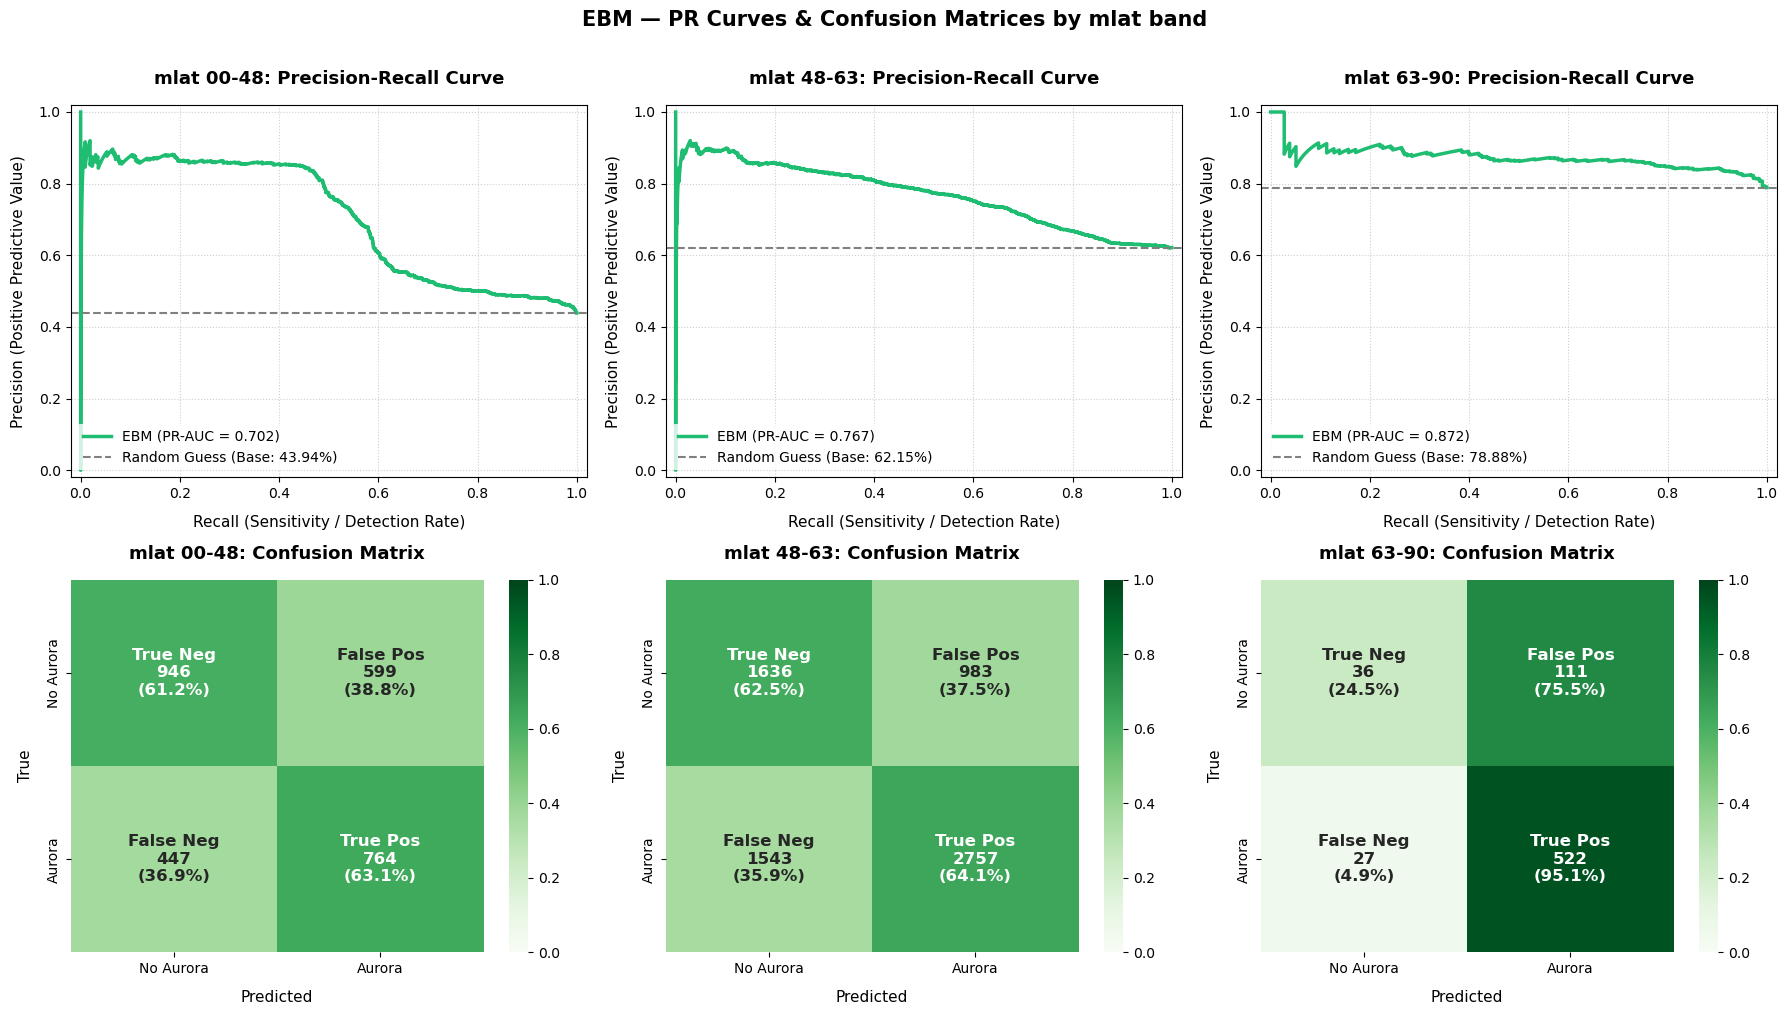

In [111]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col, band in enumerate(bands):
      grp = fit_results2_df[fit_results2_df['mlat_band'] == band]
      y_true_all = np.array(sum(grp['y_val'].tolist(),  []))
      y_prob_all = np.array(sum(grp['y_prob'].tolist(), []))
      y_pred_all = np.array(sum(grp['y_pred'].tolist(), []))

      # ── PR Curve 
      precisions, recalls, _ = precision_recall_curve(y_true_all, y_prob_all)
      pr_auc = auc(recalls, precisions)
      baseline_ratio = y_true_all.mean()

      ax = axes[0, col]
      ax.plot(recalls, precisions, color='#1ebd71', lw=2.5, label=f'EBM (PR-AUC = {pr_auc:.3f})')
      ax.axhline(y=baseline_ratio, color='gray', lw=1.5, linestyle='--',
  label=f'Random Guess (Base: {baseline_ratio:.2%})')
      ax.set_xlim([-0.02, 1.02])
      ax.set_ylim([-0.02, 1.02])
      ax.set_xlabel('Recall (Sensitivity / Detection Rate)', fontsize=11,
  labelpad=10)
      ax.set_ylabel('Precision (Positive Predictive Value)', fontsize=11,
  labelpad=10)
      ax.set_title(f'mlat {band}: Precision-Recall Curve', fontsize=13,
  weight='bold', pad=15)
      ax.grid(True, linestyle=':', alpha=0.6)
      ax.legend(loc='lower left', frameon=True, facecolor='white',
  edgecolor='none')
  
   
      cm = confusion_matrix(y_true_all, y_pred_all)
      cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)
      labels = np.array([
          [f"True Neg\n{cm[0,0]}\n({cm_normalized[0,0]:.1%})", f"False Pos\n{cm[0,1]}\n({cm_normalized[0,1]:.1%})"],
          [f"False Neg\n{cm[1,0]}\n({cm_normalized[1,0]:.1%})", f"True Pos\n{cm[1,1]}\n({cm_normalized[1,1]:.1%})"]
      ])    

      ax = axes[1, col]
      sns.heatmap(cm_normalized, annot=labels, fmt="", cmap="Greens",
  cbar=True,
                  xticklabels=['No Aurora', 'Aurora'], yticklabels=['No Aurora', 'Aurora'],
                  vmin=0, vmax=1, ax=ax, annot_kws={"size": 12, "weight":
  "bold"})  
      ax.set_xlabel('Predicted', fontsize=11, labelpad=10)
      ax.set_ylabel('True', fontsize=11, labelpad=10)
      ax.set_title(f'mlat {band}: Confusion Matrix', fontsize=13,
  weight='bold', pad=15)

plt.suptitle('EBM — PR Curves & Confusion Matrices by mlat band',
  fontsize=15, weight='bold', y=1.01)
plt.tight_layout()
plt.show()

Training on the full training set

In [112]:
sw_full = per_band_weights(
      dataclean_timesorted_alt_train[target].astype(int),
      dataclean_timesorted_alt_train['mlat_band']
  )
  
  # Sanity check weights
print("Band counts in full training set:")
print(dataclean_timesorted_alt_train['mlat_band'].value_counts())
print()
print("Weight stats per band:")
bands_arr = np.array(dataclean_timesorted_alt_train['mlat_band'])
y_arr     = np.array(dataclean_timesorted_alt_train[target].astype(int))
for band in np.unique(bands_arr[~pd.isnull(bands_arr)]):
      mask = bands_arr == band
      neg_w = sw_full[mask & (y_arr == 0)]
      pos_w = sw_full[mask & (y_arr == 1)]
      neg_str = f"{neg_w[0]:.4f}" if len(neg_w) > 0 else "N/A"
      pos_str = f"{pos_w[0]:.4f}" if len(pos_w) > 0 else "N/A"
      print(f"  {band}: neg_w={neg_str}  pos_w={pos_str}  n={mask.sum()}")


# Fit on full training set
X_train_full = dataclean_timesorted_alt_train[featureslow]
y_train_full = dataclean_timesorted_alt_train[target].astype(int)

pipeebm2.fit(X_train_full, y_train_full, EBM__sample_weight=sw_full)

# Training set predictions
y_predict_fulltrain_prob = pipeebm2.predict_proba(X_train_full)[:, 1]
y_predict_fulltrain      = (y_predict_fulltrain_prob >= 0.5).astype(int)

mlat_train_full = dataclean_timesorted_alt_train['mlat_band']
bands = sorted(dataclean_timesorted_alt_train['mlat_band'].dropna().unique())

print("\n=== Per-band Train Set Scores ===")
for band in bands:
      mask = (mlat_train_full == band).values
      if mask.sum() < 10:
            continue

      y_band    = y_train_full[mask]
      y_prob    = y_predict_fulltrain_prob[mask]
      y_pred    = y_predict_fulltrain[mask]

      print(f'\n=== {band} (n={mask.sum()}) ===')
      print(f'  F1={f1_score(y_band, y_pred):.3f}  '
            f'Recall={recall_score(y_band, y_pred):.3f}  '
            f'Precision={precision_score(y_band, y_pred):.3f}')
      print(f'  ROC-AUC={roc_auc_score(y_band, y_prob):.3f}  '
            f'PR-AUC={average_precision_score(y_band, y_prob):.3f}  '
            f'Brier={brier_score_loss(y_band, y_prob):.3f}')

        

train_scores_full = {
'f1'        : f1_score(y_train_full, y_predict_fulltrain),
'recall'    : recall_score(y_train_full, y_predict_fulltrain),
'precision' : precision_score(y_train_full, y_predict_fulltrain),
'roc_auc'   : roc_auc_score(y_train_full, y_predict_fulltrain_prob),
'pr_auc'    : average_precision_score(y_train_full, y_predict_fulltrain_prob),  
'brier'     : brier_score_loss(y_train_full, y_predict_fulltrain)}

Band counts in full training set:
mlat_band
48-63    9543
00-48    2944
63-90    1344
Name: count, dtype: int64

Weight stats per band:
  00-48: neg_w=0.8741  pos_w=1.1683  n=2944
  48-63: neg_w=1.3984  pos_w=0.7783  n=9543
  63-90: neg_w=2.8966  pos_w=0.6043  n=1344

=== Per-band Train Set Scores ===

=== 00-48 (n=2944) ===
  F1=0.687  Recall=0.721  Precision=0.657
  ROC-AUC=0.822  PR-AUC=0.779  Brier=0.171

=== 48-63 (n=9543) ===
  F1=0.808  Recall=0.782  Precision=0.837
  ROC-AUC=0.844  PR-AUC=0.902  Brier=0.160

=== 63-90 (n=1344) ===
  F1=0.848  Recall=0.788  Precision=0.918
  ROC-AUC=0.813  PR-AUC=0.949  Brier=0.181


In [113]:
print(train_scores_full)

{'f1': 0.7938922083408776, 'recall': 0.7734917088086558, 'precision': 0.8153979667741136, 'roc_auc': 0.8372738587405469, 'pr_auc': 0.8842936524153697, 'brier': 0.24690911720049166}


In [114]:
ebm_global_full = pipeebm2.named_steps['EBM'].explain_global()
show(ebm_global_full)

<!-- http://127.0.0.1:7381/140106493919152/ -->

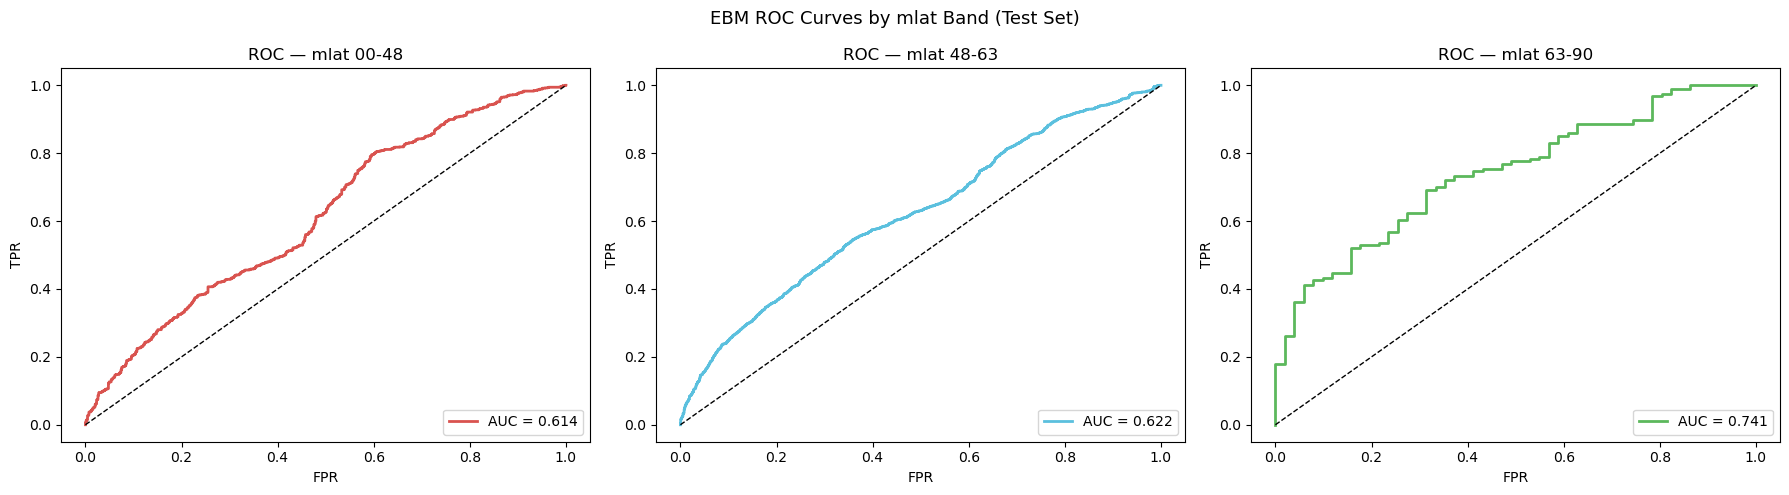

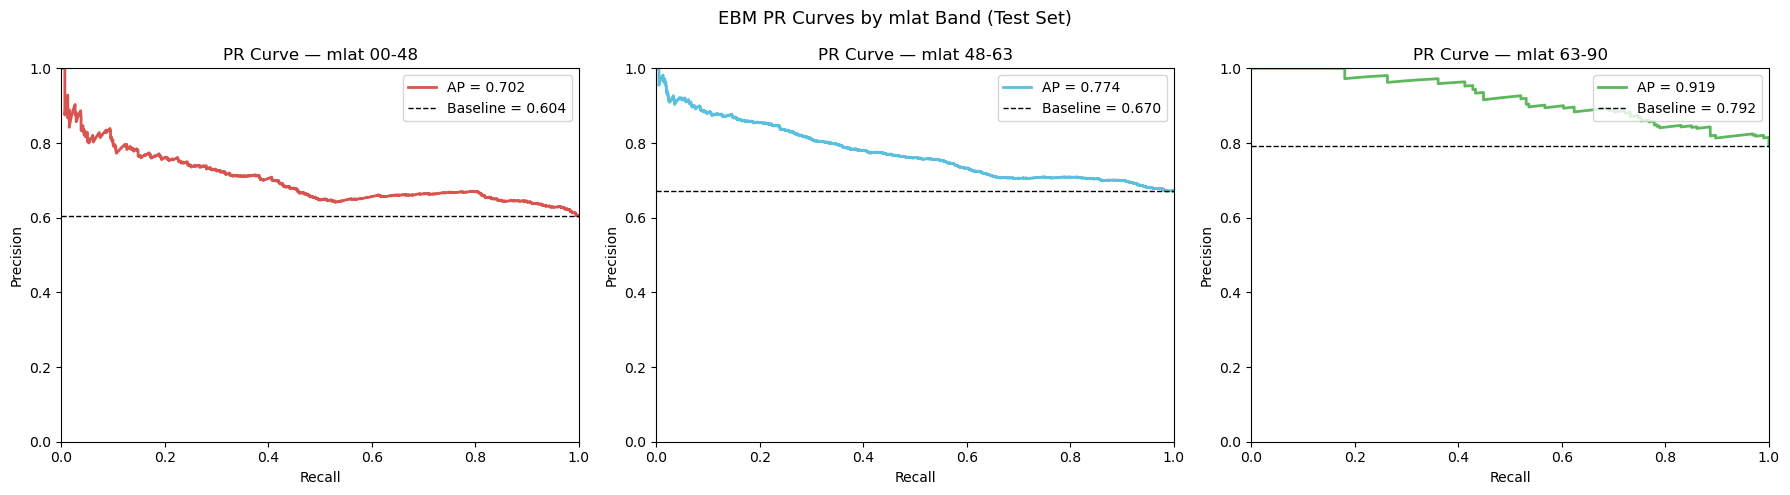

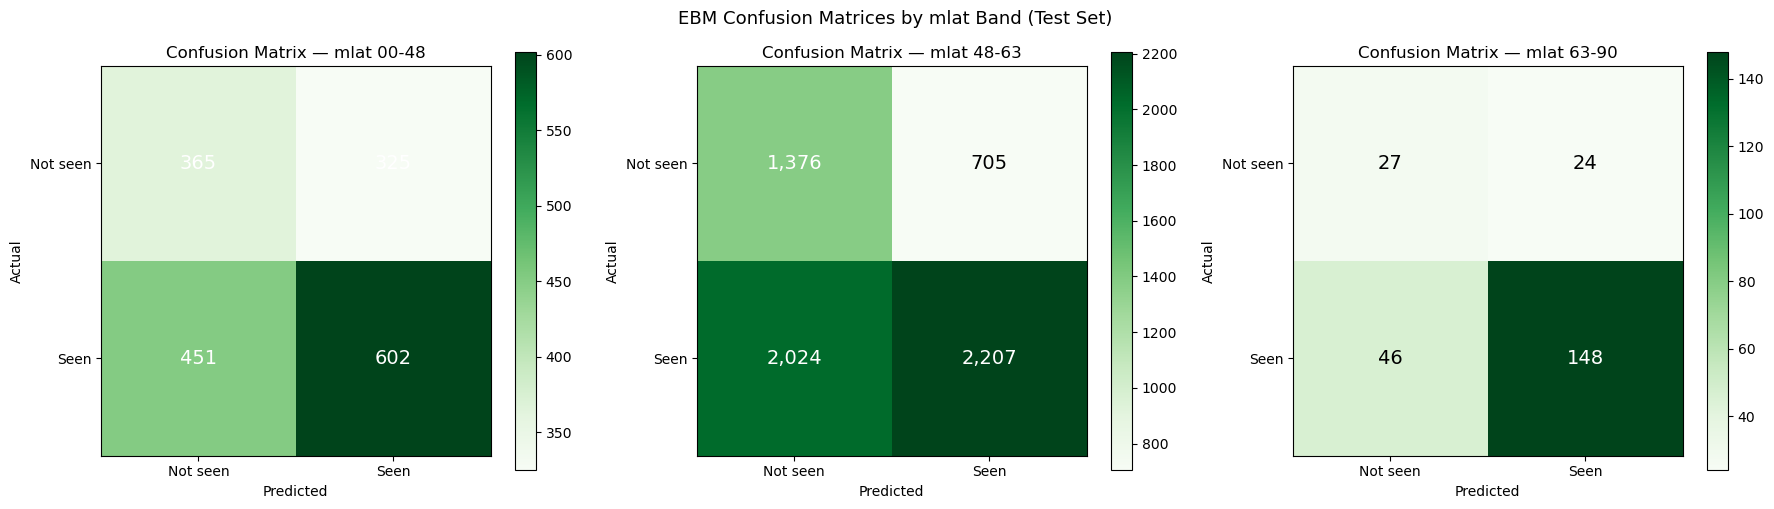

In [121]:
 # ── Test set predictions 
X_test_full      = dataclean_timesorted_alt_test[featureslow]
y_test_full      = dataclean_timesorted_alt_test[target].astype(int)
mlat_test        = dataclean_timesorted_alt_test['mlat_band']

y_predict_test_prob = pipeebm2.predict_proba(X_test_full)[:, 1]
y_predict_test      = (y_predict_test_prob >= 0.5).astype(int)

bands  = sorted(dataclean_timesorted_alt_test['mlat_band'].dropna().unique())
colors = {'00-48': '#d9534f', '48-63': '#5bc0de', '63-90': '#5cb85c'}

# ── ROC Curves 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, band in zip(axes, bands):
    mask = (mlat_test == band).values
    if mask.sum() < 10:
        continue
    fpr, tpr, _ = roc_curve(y_test_full[mask], y_predict_test_prob[mask])
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=colors[band], lw=2, label=f'AUC = {roc_auc:.3f}')
    ax.plot([0,1], [0,1], 'k--', lw=1)
    ax.set(title=f'ROC — mlat {band}', xlabel='FPR', ylabel='TPR')
    ax.legend(loc='lower right')

plt.suptitle('EBM ROC Curves by mlat Band (Test Set)', fontsize=13)
plt.tight_layout()
plt.show()

# ── PR Curves 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, band in zip(axes, bands):
    mask = (mlat_test == band).values
    if mask.sum() < 10:
        continue
    precision, recall, _ = precision_recall_curve(y_test_full[mask],y_predict_test_prob[mask])
    ap       = average_precision_score(y_test_full[mask],y_predict_test_prob[mask])
    baseline = y_test_full[mask].mean()
    ax.plot(recall, precision, color=colors[band], lw=2, label=f'AP = {ap:.3f}')
    ax.axhline(baseline, color='k', linestyle='--', lw=1, label=f'Baseline = {baseline:.3f}')
    ax.set(title=f'PR Curve — mlat {band}', xlabel='Recall',ylabel='Precision',xlim=[0,1], ylim=[0,1])
    ax.legend(loc='upper right')
plt.suptitle('EBM PR Curves by mlat Band (Test Set)', fontsize=13)
plt.tight_layout()
plt.show()

# ── Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, band in zip(axes, bands):
    mask = (mlat_test == band).values
    if mask.sum() < 10:
        continue
    cm = confusion_matrix(y_test_full[mask], y_predict_test[mask])
    im = ax.imshow(cm, interpolation='nearest', cmap='Greens')
    ax.set(title=f'Confusion Matrix — mlat {band}',
            xlabel='Predicted', ylabel='Actual',
            xticks=[0,1], yticks=[0,1],
            xticklabels=['Not seen', 'Seen'],
            yticklabels=['Not seen', 'Seen'])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{cm[i,j]:,}', ha='center', va='center',
                    color='white' if cm[i,j] > cm.max()/2 else 'black',
                    fontsize=14)
    plt.colorbar(im, ax=ax)   

plt.suptitle('EBM Confusion Matrices by mlat Band (Test Set)', fontsize=13)
plt.tight_layout()
plt.show()

In [117]:
print(pd.crosstab(dataclean_timesorted_alt_train['mlat_band'],y_predict_fulltrain))

col_0         0     1
mlat_band            
00-48      1561  1383
48-63      3814  5729
63-90       390   954


In [89]:
wrong = dataclean_timesorted_alt_train.copy()
wrong['prob'] = y_predict_fulltrain_prob
wrong['pred'] = y_predict_fulltrain

false_negatives = wrong[(wrong[target]==True)  & (wrong['pred']==0)]
false_positives = wrong[(wrong[target]==False) & (wrong['pred']==1)]

print(false_negatives[['mlat','kp','bz_gsm','cloud_cover','solar_wind_speed']]
.describe())
print(false_positives[['mlat','kp','bz_gsm','cloud_cover','solar_wind_speed']]
.describe())


              mlat           kp       bz_gsm  cloud_cover  solar_wind_speed
count  2135.000000  2135.000000  2135.000000  2135.000000       2135.000000
mean     46.383726     3.208197     0.072795    52.901639        597.484934
std      25.498055     2.458357     4.146884    42.101583        532.342860
min     -63.677530     0.000000   -19.533333     0.000000        280.000000
25%      47.433655     1.300000    -1.433333     5.000000        386.000000
50%      52.760564     2.300000     0.266667    57.000000        477.666667
75%      58.556364     4.700000     2.166667   100.000000        687.666667
max      75.695367     9.000000    21.566667   100.000000       6907.000000
              mlat           kp       bz_gsm  cloud_cover  solar_wind_speed
count  1539.000000  1539.000000  1539.000000  1539.000000       1539.000000
mean     51.808338     5.312151    -3.574334    40.508122        654.313840
std      10.348927     2.478640     7.327586    41.292847        456.601359
min     -53.

(array([474., 479., 355., 454., 395., 408., 475., 444., 499., 518., 511.,
        539., 569., 613., 695., 725., 722., 700., 684., 663., 882., 981.,
        682., 272.,  92.]),
 array([0.01286482, 0.05199676, 0.09112869, 0.13026063, 0.16939257,
        0.20852451, 0.24765645, 0.28678839, 0.32592033, 0.36505227,
        0.4041842 , 0.44331614, 0.48244808, 0.52158002, 0.56071196,
        0.5998439 , 0.63897584, 0.67810777, 0.71723971, 0.75637165,
        0.79550359, 0.83463553, 0.87376747, 0.91289941, 0.95203135,
        0.99116328]),
 <BarContainer object of 25 artists>)

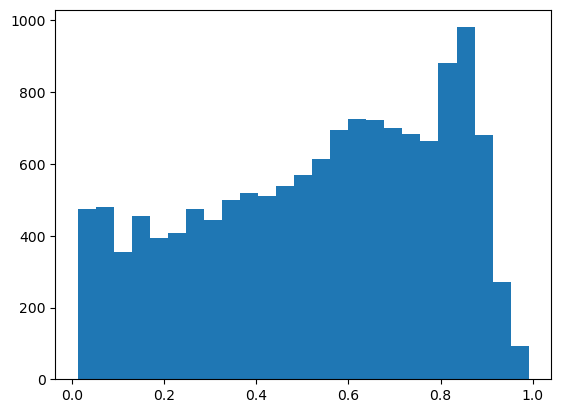

In [126]:
plt.hist(y_predict_fulltrain_prob, bins=25)

In [128]:
y_test_arr   = dataclean_timesorted_alt_test["see_aurora"]
probs_test   = pipeebm2.predict_proba(dataclean_timesorted_alt_test[featureslow])[:, 1]
preds_test   = (probs_test >= 0.3).astype(int)

fn_mask = (y_test_arr == 1) & (preds_test == 0)
fn_idx  = np.where(fn_mask)[0]
print(f'False negatives: {fn_mask.sum()}')
print(dataclean_timesorted_alt_test[featureslow].iloc[fn_idx[:5]][['mlat', 'kp', 'bz_gsm', 'oval_dist',
'sun_elevation_utc']])

# Pick first false negative and explain
sample_idx = fn_idx[0]
X_fn = dataclean_timesorted_alt_test[featureslow].iloc[[sample_idx]]
y_fn = dataclean_timesorted_alt_test["see_aurora"].iloc[[sample_idx]]

X_fn_transformed = pipeebm2[:-1].transform(X_fn)

ebm = pipeebm2.named_steps['EBM']
show(ebm.explain_local(X_fn_transformed, y_fn.values), 0)

False negatives: 1000
            mlat   kp    bz_gsm  oval_dist  sun_elevation_utc
13833  55.178312  1.0 -0.600000 -10.204226           6.360679
13848  47.588970  1.0  1.366667 -17.058736           2.809571
13849  47.598849  1.0  1.366667 -17.048606           1.231615
13850  47.605425  0.7  1.500000 -17.763407           0.705059
13851  47.606452  0.7  1.500000 -17.761899           0.383715


<!-- http://127.0.0.1:7381/140106496679072/ -->

In [129]:
y_test_arr   = dataclean_timesorted_alt_test["see_aurora"]
probs_test   = pipeebm2.predict_proba(dataclean_timesorted_alt_test[featureslow])[:, 1]
preds_test   = (probs_test >= 0.3).astype(int)

fn_mask = (y_test_arr == 0) & (preds_test == 1)
fn_idx  = np.where(fn_mask)[0]
print(f'False positive: {fn_mask.sum()}')
print(dataclean_timesorted_alt_test[featureslow].iloc[fn_idx[:5]][['mlat', 'kp', 'bz_gsm', 'oval_dist',
'sun_elevation_utc']])

# Pick first false negative and explain
sample_idx = fn_idx[0]
X_fn = dataclean_timesorted_alt_test[featureslow].iloc[[sample_idx]]
y_fn = dataclean_timesorted_alt_test["see_aurora"].iloc[[sample_idx]]

X_fn_transformed = pipeebm2[:-1].transform(X_fn)

ebm = pipeebm2.named_steps['EBM']
show(ebm.explain_local(X_fn_transformed, y_fn.values), 0)

False positive: 1936
            mlat   kp        bz_gsm  oval_dist  sun_elevation_utc
13832  59.998384  0.3 -3.000000e-01  -7.017651           1.409012
13835  36.852212  1.0  1.666667e+00 -27.012890           5.744899
13838  59.991687  2.0 -1.666667e+00  -1.539551           8.424664
13840  56.463854  2.0 -1.666667e+00  -6.554461         -16.110179
13841  57.137956  3.0  1.480297e-16  -3.683444          48.930445


<!-- http://127.0.0.1:7381/140107605484528/ -->

# Predictions based on limited July 4th, 2026 geomagnetic indices data

Max prob    : 0.9529
Mean prob   : 0.7756
probs >= 0.3: 11041
probs >= 0.5: 11035
probs >= 0.7: 8640


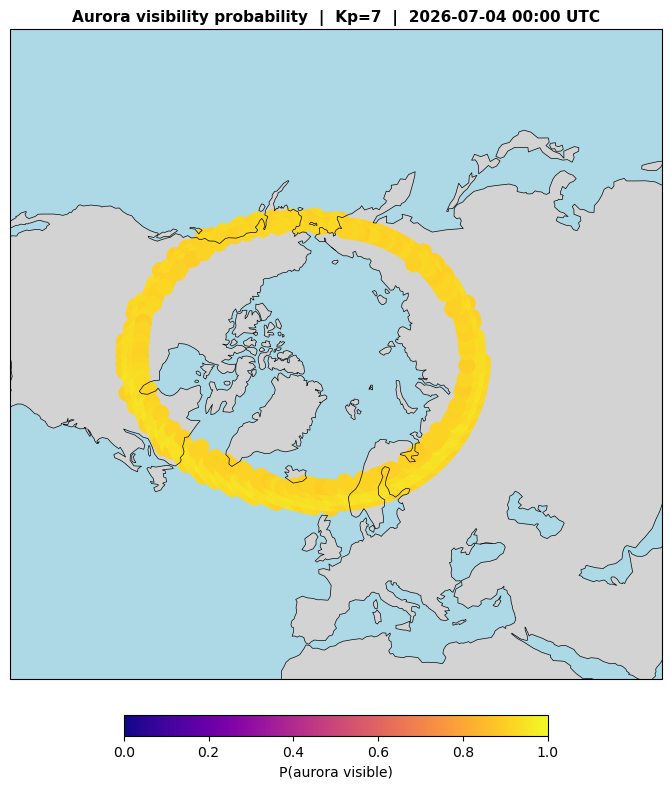

In [130]:
import aacgmv2
import datetime                                       
import cartopy.crs as ccrs
import cartopy.feature as cfeature
KP_TO_AP = {0:0, 1:3, 2:7, 3:15, 4:27, 5:48, 6:80, 7:140, 8:240, 9:400}

kp_input = 7
dt       = datetime.datetime(2026, 7, 4, 0, 0, 0)

# ── Geographic grid 
geo_lats = np.arange(30, 91, 1, dtype=float)
geo_lons = np.arange(-180, 181, 2, dtype=float)
geo_lon_mesh, geo_lat_mesh = np.meshgrid(geo_lons, geo_lats)

geo_lat_flat = geo_lat_mesh.flatten()
geo_lon_flat = geo_lon_mesh.flatten()

# ── AACGM conversion: geographic → mlat, mlon, mlt 
mlat_flat, mlon_flat, mlt_flat = aacgmv2.get_aacgm_coord_arr(
    geo_lat_flat, geo_lon_flat,
    np.zeros_like(geo_lat_flat), 
    dt
)

# ── oval_dist — Zhang & Paxton MLT-aware formula 
mlt_angle      = np.pi * mlt_flat / 12
oval_dist_flat = mlat_flat - (65.2 - 2.4 * kp_input + 3.0 *
np.cos(mlt_angle))

# ── Build prediction DataFrame 
sweep_df = pd.DataFrame({
    'mlat':              mlat_flat,
    'mlon':              mlon_flat,
    'kp':                float(kp_input),
    'bz_gsm':           -10.0,
    'sigma_bz_gsm':      4.0,
    'solar_wind_speed':  650.0,
    'Ap':                float(KP_TO_AP.get(kp_input, 27)),
    'oval_dist':         oval_dist_flat,
    'cloud_cover':       0.0,
    'sun_elevation_utc': -30.0,
    'moon_darkness':     1.0,
})

# Drop rows where AACGM returned NaN
valid = sweep_df.notna().all(axis=1)
probs = np.full(len(sweep_df), np.nan)
probs[valid] = pipeebm2.predict_proba(sweep_df.loc[valid, featureslow])[:,
1]

print(f'Max prob    : {np.nanmax(probs):.4f}')
print(f'Mean prob   : {np.nanmean(probs):.4f}')
print(f'probs >= 0.3: {(probs >= 0.3).sum()}')
print(f'probs >= 0.5: {(probs >= 0.5).sum()}')
print(f'probs >= 0.7: {(probs >= 0.7).sum()}')

# ── Plot 
threshold = 0.90
mask = (probs >= threshold) & ~np.isnan(probs)

fig, ax = plt.subplots(1, 1, figsize=(8, 8),
                        subplot_kw={'projection': ccrs.NorthPolarStereo()})

ax.add_feature(cfeature.LAND,      facecolor='lightgray')
ax.add_feature(cfeature.OCEAN,     facecolor='lightblue')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.set_extent([-180, 180, 30, 90], crs=ccrs.PlateCarree())

if mask.sum() > 0:  
    sc = ax.scatter(
      geo_lon_flat[mask], geo_lat_flat[mask],
      c=probs[mask], cmap='plasma', vmin=0, vmax=1,
      s=150, marker='o', linewidths=0,
      transform=ccrs.PlateCarree()
  )

    plt.colorbar(sc, ax=ax, orientation='horizontal',
                fraction=0.03, pad=0.05, label='P(aurora visible)')
else:
    ax.text(0.5, 0.5, 'No points above threshold',
            ha='center', va='center', transform=ax.transAxes, fontsize=12)

ax.set_title(f'Aurora visibility probability  |  Kp={kp_input}  |  '
            f'{dt.strftime("%Y-%m-%d %H:%M UTC")}',
            fontsize=11, weight='bold')

plt.tight_layout()
plt.show()